In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("seaborn-v0_8-whitegrid")
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [76]:
zeta15 = pd.read_csv("zeta15/results/evaluation.csv")
zeta50 = pd.read_csv("zeta50/results/evaluation.csv")
zeta85 = pd.read_csv("zeta85/results/evaluation.csv")

In [77]:
epsilons = np.linspace(0, 1, 21)
stage_labels = [fr"Stage {stage} ($\epsilon={round(epsilons[stage-1], 3)})$" for stage in range(1, 22)]
ticklabels = ['Random'] + stage_labels

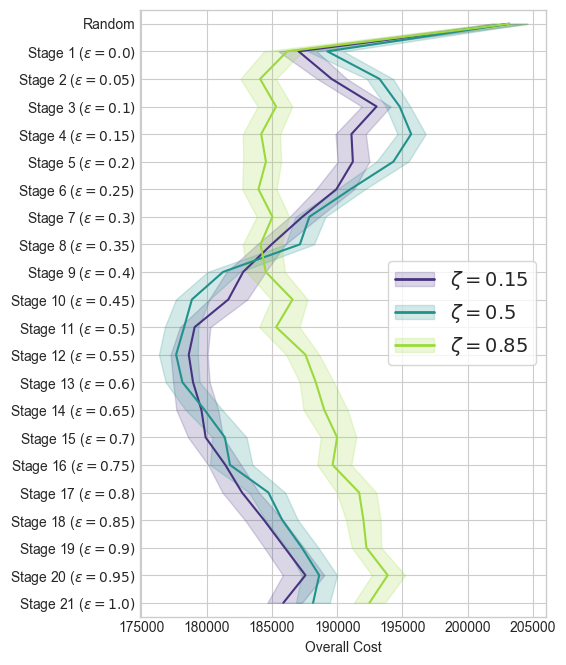

In [93]:
fig, ax = plt.subplots(1, figsize=(5.75, 6.75))
cmap = plt.cm.viridis
colours = {0.15: cmap(0.15), 0.50: cmap(0.5), 0.85: cmap(0.85)}

ax.plot(zeta15.median(), range(22), c=colours[0.15])
ax.fill_betweenx(range(22), zeta15.quantile(0.25), zeta15.quantile(0.75), alpha=0.2, color=colours[0.15])

ax.plot(zeta50.median(), range(22), c=colours[0.5])
ax.fill_betweenx(range(22), zeta50.quantile(0.25), zeta50.quantile(0.75), alpha=0.2, color=colours[0.5])

ax.plot(zeta85.median(), range(22), c=colours[0.85])
ax.fill_betweenx(range(22), zeta85.quantile(0.25), zeta85.quantile(0.75), alpha=0.2, color=colours[0.85])
ax.set_ylim(-0.5, 21.5)

legend_handles = [
    (mpatches.Patch(facecolor=colours[0.15], edgecolor=colours[0.15], alpha=0.2), Line2D([0], [0], color=colours[0.15], lw=2)),
    (mpatches.Patch(facecolor=colours[0.5], edgecolor=colours[0.5], alpha=0.2), Line2D([0], [0], color=colours[0.5], lw=2)),
    (mpatches.Patch(facecolor=colours[0.85], edgecolor=colours[0.85], alpha=0.2), Line2D([0], [0], color=colours[0.85], lw=2)),
]
legend_labels = [
    r"$\zeta = 0.15$",
    r"$\zeta = 0.5$",
    r"$\zeta = 0.85$"
]

ax.invert_yaxis()
ax.set_yticks(range(22))
ax.set_yticklabels(ticklabels)
ax.set_xlabel("Overall Cost")
ax.legend(handles=legend_handles, labels=legend_labels, fontsize=14, frameon=True)
plt.tight_layout()
fig.savefig("../../../plt/vary_zeta.pdf")